# SP(k) Validation Notebook (CCL vs pyspk)

This notebook provides a compact, unit-consistent validation of the CCL SP(k) wrapper.

It checks that:
- `BaryonsSPK.boost_factor` from `pyccl` matches direct `pyspk` output
- the agreement is stable across multiple redshifts on the same `k` grid
- differences stay at numerical roundoff scale

## Units
- `pyccl` follows CCL conventions: user-facing `k` is in `Mpc^-1`
- `pyspk` expects `k` in `h/Mpc`

`BaryonsSPK` converts `k` internally from `Mpc^-1` to `h/Mpc`.
Public constructor ranges (`k_min_mpc`, `k_max_mpc`) are also in `Mpc^-1`.
In this notebook we still build both grids explicitly, because we compare against direct `pyspk` calls.

In [1]:
from typing import Literal, cast

import matplotlib.pyplot as plt
import numpy as np
import pyccl as ccl

try:
    import pyspk
except ImportError as err:
    raise ImportError(
        "This notebook requires pyspk. Install with: pip install 'pyspk>=2.0.0'"
    ) from err

In [2]:
# Configuration
SO = 200
relation_kind: Literal["power_law"] = "power_law"

# Relation parameters for relation_kind="power_law"
fb_a = 0.4
fb_pow = 0.2
fb_pivot = 10**13.5

# Keep grouped params for CCL wrapper construction
relation_params = {
    "fb_a": fb_a,
    "fb_pow": fb_pow,
    "fb_pivot": fb_pivot,
}

# Reference cosmology (used for h and E(z) when needed)
cosmo = ccl.CosmologyVanillaLCDM(transfer_function="bbks")
h = cast(float, cosmo["h"])

# Internal SP(k) grid configuration for direct pyspk calls (h/Mpc)
k_min_hmpc = 0.01
k_max_hmpc = 12.0
n_k = 400
k_hmpc = np.geomspace(k_min_hmpc, k_max_hmpc, n_k)

# CCL-facing range configuration (Mpc^-1) used by BaryonsSPK constructor
k_min_mpc = k_min_hmpc * h
k_max_mpc = k_max_hmpc * h

# Target grid and redshifts for comparison
z_arr = np.array([0.125, 1.0, 3.0])
a_arr = 1.0 / (1.0 + z_arr)

# For direct pyspk comparison only: convert h/Mpc -> Mpc^-1 for CCL call sites.
k_mpc = k_hmpc * h

print(f"relation_kind = {relation_kind}")
print(f"SO = {SO}")
print(f"h = {h:.5f}")
print(f"k_hmpc range: {k_hmpc.min():.3e} -> {k_hmpc.max():.3e}")
print(f"k_mpc range:  {k_mpc.min():.3e} -> {k_mpc.max():.3e}")
print(f"z grid: {z_arr}")

relation_kind = power_law
SO = 200
h = 0.67000
k_hmpc range: 1.000e-02 -> 1.200e+01
k_mpc range:  6.700e-03 -> 8.040e+00
z grid: [0.125 1.    3.   ]


In [3]:
# CCL suppression from BaryonsSPK
bar_spk = ccl.BaryonsSPK(
    SO=SO,
    relation_kind=relation_kind,
    k_min_mpc=k_min_mpc,
    k_max_mpc=k_max_mpc,
    n_k=n_k,
    out_of_bounds_policy="error",
    **relation_params,
)

# k_mpc is passed in Mpc^-1; BaryonsSPK handles Mpc^-1 -> h/Mpc internally.
S_ccl = np.vstack([bar_spk.boost_factor(cosmo, k_mpc, a) for a in a_arr])
print("Computed S_ccl from BaryonsSPK.boost_factor.")

Computed S_ccl from BaryonsSPK.boost_factor.


In [4]:
# Direct pyspk suppression on the same k_hmpc grid
S_pyspk = np.empty_like(S_ccl)
for i, z in enumerate(z_arr):
    _, sup = pyspk.sup_model(
        SO=SO,
        z=float(z),
        fb_a=fb_a,
        fb_pow=fb_pow,
        fb_pivot=fb_pivot,
        k_array=k_hmpc,
    )
    S_pyspk[i, :] = sup

print("Agreement summary (CCL vs pyspk)")
max_abs_all = 0.0
max_rel_all = 0.0
for i, z in enumerate(z_arr):
    diff = S_ccl[i] - S_pyspk[i]
    with np.errstate(divide="ignore", invalid="ignore"):
        rel = np.abs(diff) / np.maximum(np.abs(S_pyspk[i]), 1.0e-12)
    max_abs = float(np.nanmax(np.abs(diff)))
    max_rel = float(np.nanmax(rel))
    max_abs_all = max(max_abs_all, max_abs)
    max_rel_all = max(max_rel_all, max_rel)
    print(f"z={z:.3g}: max|ΔS|={max_abs:.3e}, max rel|ΔS|={max_rel:.3e}")

print(f"global max|ΔS|={max_abs_all:.3e}")
print(f"global max rel|ΔS|={max_rel_all:.3e}")

Agreement summary (CCL vs pyspk)
z=0.125: max|ΔS|=3.331e-16, max rel|ΔS|=3.425e-16
z=1: max|ΔS|=2.220e-16, max rel|ΔS|=2.844e-16
z=3: max|ΔS|=2.220e-16, max rel|ΔS|=2.611e-16
global max|ΔS|=3.331e-16
global max rel|ΔS|=3.425e-16


/var/folders/mm/97jkmxws1v5381f7n2hfm_9w0000gn/T/ipykernel_25935/4234634099.py:4: UserWarning: Scales with k_max > k_ny = 8.0 [h/Mpc] may not be accurately reproduced by the model.
  _, sup = pyspk.sup_model(
/var/folders/mm/97jkmxws1v5381f7n2hfm_9w0000gn/T/ipykernel_25935/4234634099.py:4: UserWarning: Found baryon fraction values outside fitting limits. fb < lower_limit between 1.8e+12 <= M_halo [M_sun] <= 1.8e+12. sup_model() will return NaNs within those limits.
  _, sup = pyspk.sup_model(


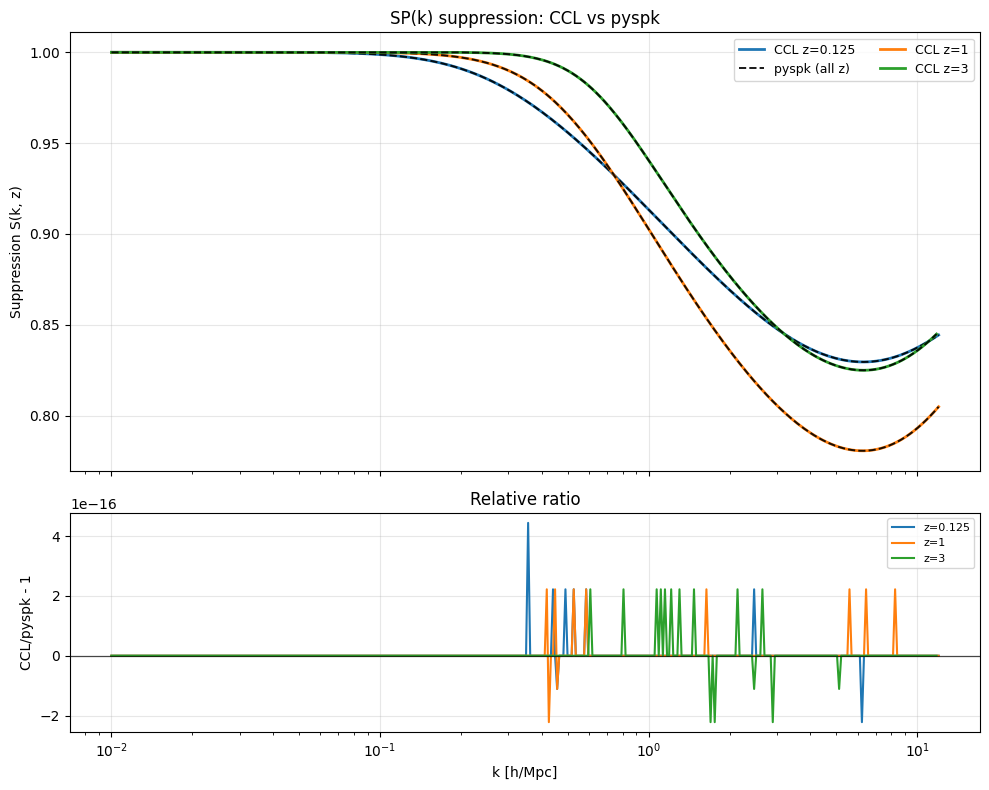

In [5]:
# Plot: suppression (top) and relative ratio (bottom)
fig, axes = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
 )
ax_top, ax_bot = axes

for i, z in enumerate(z_arr):
    # CCL curves (colored)
    ax_top.plot(k_hmpc, S_ccl[i], lw=2.0, label=f"CCL z={z:.3g}")

    # pyspk curves: all black dashed; show legend entry only once
    pyspk_label = "pyspk (all z)" if i == 0 else None
    ax_top.plot(
        k_hmpc, S_pyspk[i], "k--", lw=1.4, alpha=0.9, label=pyspk_label
    )

    # Relative ratio panel: (CCL/pyspk - 1)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = S_ccl[i] / np.maximum(S_pyspk[i], 1.0e-12) - 1.0
    ratio[~np.isfinite(ratio)] = np.nan
    ax_bot.plot(k_hmpc, ratio, lw=1.5, label=f"z={z:.3g}")

ax_top.set_xscale("log")
ax_top.set_ylabel("Suppression S(k, z)")
ax_top.set_title("SP(k) suppression: CCL vs pyspk")
ax_top.grid(alpha=0.3)
ax_top.legend(fontsize=9, ncol=2)

ax_bot.set_xscale("log")
ax_bot.set_xlabel("k [h/Mpc]")
ax_bot.set_ylabel("CCL/pyspk - 1")
ax_bot.set_title("Relative ratio")
ax_bot.axhline(0.0, color="black", lw=0.9, alpha=0.7)
ax_bot.grid(alpha=0.3)
ax_bot.legend(fontsize=8)

fig.tight_layout()
plt.show()